# EDA — MovieLens Latest Small

Exploratory analysis of the raw dataset before any filtering or preprocessing.  
Two figures:
- **Part 1** — Core distributions: ratings, user activity, movie activity, long-tail, temporal patterns
- **Part 2** — User & genre behaviour: rating bias, polarisation, genre popularity, half-star usage


## 1. Imports & Plot Style

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

BG, PANEL, GRID_C = "#0f0f14", "#16161f", "#2a2a35"
TEXT_C, ACCENT, ACCENT2, ACCENT3 = "#d4d4e0", "#7DF9C4", "#F97D7D", "#7DA8F9"

def style_ax(ax, title):
    ax.set_facecolor(PANEL)
    ax.set_title(title, color=TEXT_C, fontsize=10, pad=9, fontweight="bold")
    ax.tick_params(colors=TEXT_C, labelsize=8)
    ax.xaxis.label.set_color(TEXT_C)
    ax.yaxis.label.set_color(TEXT_C)
    for spine in ax.spines.values():
        spine.set_edgecolor(GRID_C)
    ax.grid(color=GRID_C, linewidth=0.5, linestyle="--", alpha=0.7)


## 2. Load Data

In [3]:
ratings = pd.read_csv("../data/raw/ratings.csv")
movies  = pd.read_csv("../data/raw/movies.csv")

ratings["timestamp"] = pd.to_datetime(ratings["timestamp"], unit="s")
ratings["year"]  = ratings["timestamp"].dt.year
ratings["month"] = ratings["timestamp"].dt.month

df = ratings.merge(movies, on="movieId")

print(f"Ratings : {len(ratings):,}")
print(f"Users   : {ratings.userId.nunique():,}")
print(f"Movies  : {ratings.movieId.nunique():,}")
print(f"Date range: {ratings.timestamp.min().date()} → {ratings.timestamp.max().date()}")


Ratings : 100,836
Users   : 610
Movies  : 9,724
Date range: 1996-03-29 → 2018-09-24


## 3. Summary Statistics

In [4]:
n_users   = ratings["userId"].nunique()
n_movies  = ratings["movieId"].nunique()
n_ratings = len(ratings)
sparsity  = 1 - n_ratings / (n_users * n_movies)

ratings_per_user  = ratings.groupby("userId")["rating"].count()
ratings_per_movie = ratings.groupby("movieId")["rating"].count()

print(f"Sparsity       : {sparsity:.4%}")
print(f"Rating range   : {ratings.rating.min()} – {ratings.rating.max()}")
print(f"Mean rating    : {ratings.rating.mean():.3f}")
print(f"Median rating  : {ratings.rating.median():.1f}")
print()
print("Ratings per user")
print(f"  min={ratings_per_user.min()}  median={ratings_per_user.median():.0f}  "
      f"mean={ratings_per_user.mean():.1f}  max={ratings_per_user.max()}")
print()
print("Ratings per movie")
print(f"  min={ratings_per_movie.min()}  median={ratings_per_movie.median():.0f}  "
      f"mean={ratings_per_movie.mean():.1f}  max={ratings_per_movie.max()}")
print()

cold_users  = (ratings_per_user  < 5).sum()
cold_movies = (ratings_per_movie < 5).sum()
print(f"Users  with < 5 ratings : {cold_users}  ({cold_users/n_users:.1%})")
print(f"Movies with < 5 ratings : {cold_movies} ({cold_movies/n_movies:.1%})")
print()

all_genres   = df["genres"].str.split("|").explode()
genre_counts = all_genres.value_counts()
print("Top 10 genres:")
for g, c in genre_counts.head(10).items():
    print(f"  {g:<20} {c:,}")
print()

half_star = (ratings["rating"] % 1 != 0).mean()
print(f"Half-star ratings : {half_star:.1%}")


Sparsity       : 98.3000%
Rating range   : 0.5 – 5.0
Mean rating    : 3.502
Median rating  : 3.5

Ratings per user
  min=20  median=70  mean=165.3  max=2698

Ratings per movie
  min=1  median=3  mean=10.4  max=329

Users  with < 5 ratings : 0  (0.0%)
Movies with < 5 ratings : 6074 (62.5%)

Top 10 genres:
  Drama                41,928
  Comedy               39,053
  Action               30,635
  Thriller             26,452
  Adventure            24,161
  Romance              18,124
  Sci-Fi               17,243
  Crime                16,681
  Fantasy              11,834
  Children             9,208

Half-star ratings : 30.1%


## 4. Part 1 — Core Distributions

Six panels:
- **Rating distribution** — overall skew toward positive ratings
- **Ratings per user** — how active users are
- **Ratings per movie** — long-tail signal
- **Long-tail curve** — cumulative % of ratings vs % of movies
- **Mean rating per movie** — for movies with ≥20 ratings (enough to be reliable)
- **Rating activity over time** — temporal patterns


C:\Users\Hites\AppData\Local\Temp\ipykernel_8756\4166135195.py:73: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


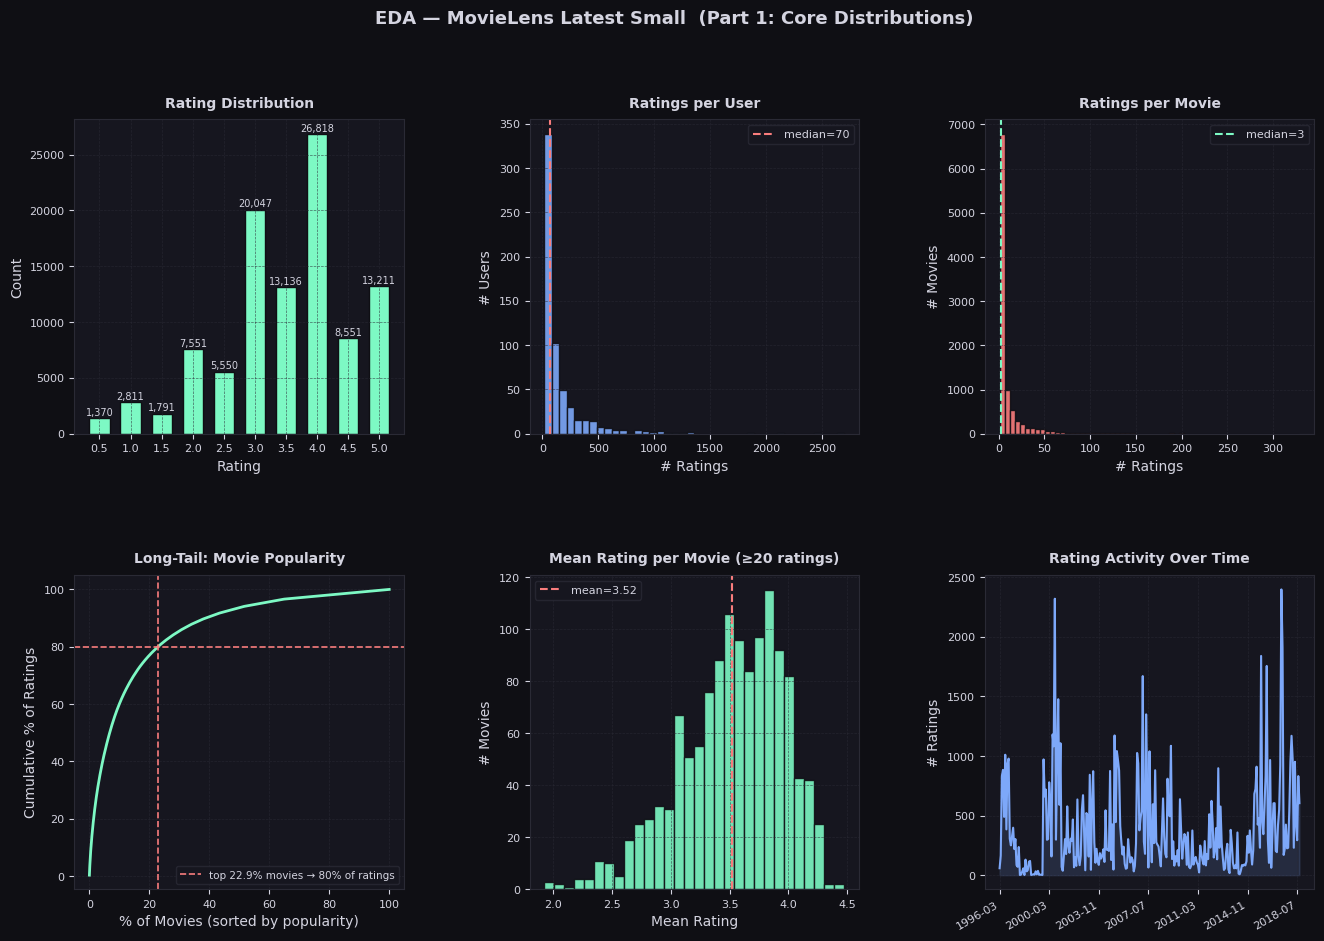

In [5]:
fig1 = plt.figure(figsize=(16, 10))
fig1.patch.set_facecolor(BG)
gs1 = gridspec.GridSpec(2, 3, figure=fig1, hspace=0.45, wspace=0.38)

# (a) Rating distribution
ax = fig1.add_subplot(gs1[0, 0])
counts = ratings["rating"].value_counts().sort_index()
bars = ax.bar(counts.index.astype(str), counts.values, color=ACCENT, edgecolor=BG, width=0.65)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 100,
            f"{b.get_height():,}", ha="center", va="bottom", color=TEXT_C, fontsize=7)
ax.set_xlabel("Rating"); ax.set_ylabel("Count")
style_ax(ax, "Rating Distribution")

# (b) Ratings per user
ax = fig1.add_subplot(gs1[0, 1])
ax.hist(ratings_per_user, bins=40, color=ACCENT3, edgecolor=BG, alpha=0.9)
ax.axvline(ratings_per_user.median(), color=ACCENT2, lw=1.5, linestyle="--",
           label=f"median={ratings_per_user.median():.0f}")
ax.set_xlabel("# Ratings"); ax.set_ylabel("# Users")
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
style_ax(ax, "Ratings per User")

# (c) Ratings per movie
ax = fig1.add_subplot(gs1[0, 2])
ax.hist(ratings_per_movie, bins=60, color=ACCENT2, edgecolor=BG, alpha=0.9)
ax.axvline(ratings_per_movie.median(), color=ACCENT, lw=1.5, linestyle="--",
           label=f"median={ratings_per_movie.median():.0f}")
ax.set_xlabel("# Ratings"); ax.set_ylabel("# Movies")
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
style_ax(ax, "Ratings per Movie")

# (d) Long-tail curve
ax = fig1.add_subplot(gs1[1, 0])
sorted_counts = ratings_per_movie.sort_values(ascending=False).values
cum_ratings = np.cumsum(sorted_counts) / sorted_counts.sum() * 100
cum_movies  = np.arange(1, len(sorted_counts)+1) / len(sorted_counts) * 100
ax.plot(cum_movies, cum_ratings, color=ACCENT, lw=2)
idx_80 = np.searchsorted(cum_ratings, 80)
ax.axvline(cum_movies[idx_80], color=ACCENT2, lw=1.2, linestyle="--")
ax.axhline(80, color=ACCENT2, lw=1.2, linestyle="--",
           label=f"top {cum_movies[idx_80]:.1f}% movies → 80% of ratings")
ax.set_xlabel("% of Movies (sorted by popularity)")
ax.set_ylabel("Cumulative % of Ratings")
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=7.5)
style_ax(ax, "Long-Tail: Movie Popularity")

# (e) Mean rating per movie (≥20 ratings)
ax = fig1.add_subplot(gs1[1, 1])
mean_per_movie = df.groupby("movieId")["rating"].agg(["mean","count"])
well_rated = mean_per_movie[mean_per_movie["count"] >= 20]["mean"]
ax.hist(well_rated, bins=30, color=ACCENT, edgecolor=BG, alpha=0.9)
ax.axvline(well_rated.mean(), color=ACCENT2, lw=1.5, linestyle="--",
           label=f"mean={well_rated.mean():.2f}")
ax.set_xlabel("Mean Rating"); ax.set_ylabel("# Movies")
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
style_ax(ax, "Mean Rating per Movie (≥20 ratings)")

# (f) Ratings over time
ax = fig1.add_subplot(gs1[1, 2])
monthly = ratings.groupby(ratings["timestamp"].dt.to_period("M")).size()
ax.plot(monthly.index.astype(str), monthly.values, color=ACCENT3, lw=1.5)
ax.fill_between(range(len(monthly)), monthly.values, alpha=0.15, color=ACCENT3)
tick_every = max(1, len(monthly) // 6)
ax.set_xticks(range(0, len(monthly), tick_every))
ax.set_xticklabels([str(monthly.index[i]) for i in range(0, len(monthly), tick_every)],
                   rotation=30, ha="right", fontsize=7)
ax.set_ylabel("# Ratings")
style_ax(ax, "Rating Activity Over Time")

fig1.suptitle("EDA — MovieLens Latest Small  (Part 1: Core Distributions)",
              color=TEXT_C, fontsize=13, fontweight="bold", y=0.99)
plt.tight_layout()
plt.show()


## 5. Part 2 — User & Genre Behaviour

Six panels:
- **Per-user mean rating** — captures rating bias (harsh vs generous raters). Wide spread = `b_u` term will matter.
- **Per-user rating std** — how polarised vs centrist each user is
- **Genre popularity** — number of movies per genre
- **Mean rating by genre** — with ±1 std error bars, filtered to genres with ≥100 ratings
- **Half-star vs whole-star usage** — users prefer round numbers
- **Top 15 most-rated movies** — popularity concentration


C:\Users\Hites\AppData\Local\Temp\ipykernel_8756\818488240.py:76: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


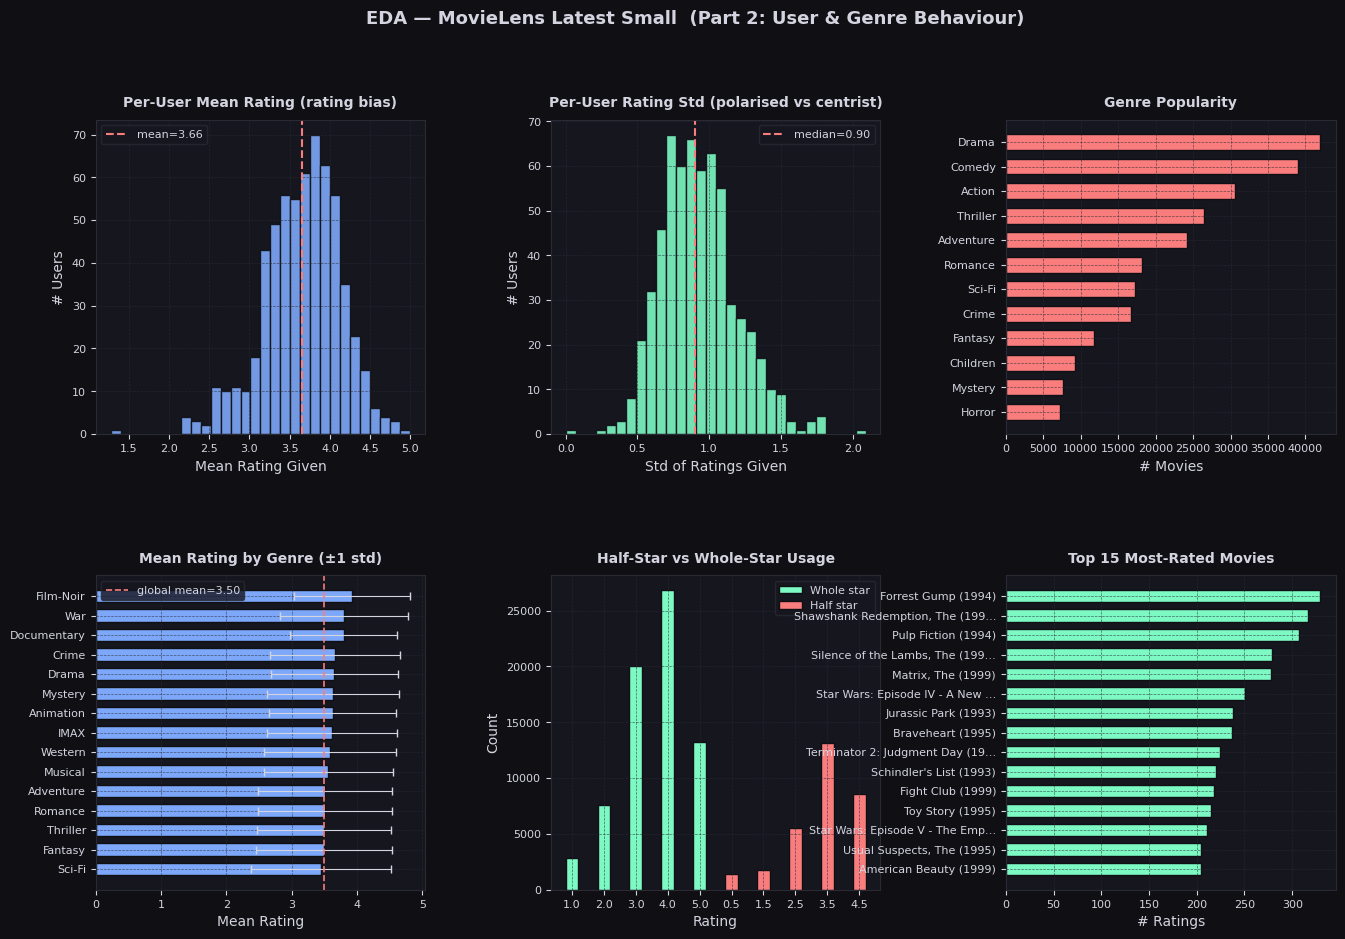

In [6]:
fig2 = plt.figure(figsize=(16, 10))
fig2.patch.set_facecolor(BG)
gs2 = gridspec.GridSpec(2, 3, figure=fig2, hspace=0.45, wspace=0.38)

# (a) Per-user mean rating
ax = fig2.add_subplot(gs2[0, 0])
user_mean = ratings.groupby("userId")["rating"].mean()
ax.hist(user_mean, bins=30, color=ACCENT3, edgecolor=BG, alpha=0.9)
ax.axvline(user_mean.mean(), color=ACCENT2, lw=1.5, linestyle="--",
           label=f"mean={user_mean.mean():.2f}")
ax.set_xlabel("Mean Rating Given"); ax.set_ylabel("# Users")
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
style_ax(ax, "Per-User Mean Rating (rating bias)")

# (b) Per-user rating std
ax = fig2.add_subplot(gs2[0, 1])
user_std = ratings.groupby("userId")["rating"].std().dropna()
ax.hist(user_std, bins=30, color=ACCENT, edgecolor=BG, alpha=0.9)
ax.axvline(user_std.median(), color=ACCENT2, lw=1.5, linestyle="--",
           label=f"median={user_std.median():.2f}")
ax.set_xlabel("Std of Ratings Given"); ax.set_ylabel("# Users")
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
style_ax(ax, "Per-User Rating Std (polarised vs centrist)")

# (c) Genre popularity
ax = fig2.add_subplot(gs2[0, 2])
top_genres = genre_counts.head(12)
ax.barh(top_genres.index[::-1], top_genres.values[::-1], color=ACCENT2, edgecolor=BG, height=0.65)
ax.set_xlabel("# Movies")
style_ax(ax, "Genre Popularity")

# (d) Mean rating by genre ±1 std
ax = fig2.add_subplot(gs2[1, 0])
genre_rating = (
    df.assign(genre=df["genres"].str.split("|"))
      .explode("genre")
      .groupby("genre")["rating"]
      .agg(["mean", "std", "count"])
      .query("count >= 100")
      .sort_values("mean", ascending=False)
      .head(15)
)
ax.barh(genre_rating.index[::-1], genre_rating["mean"][::-1],
        xerr=genre_rating["std"][::-1], color=ACCENT3, edgecolor=BG, height=0.65,
        error_kw={"ecolor": TEXT_C, "capsize": 3, "linewidth": 0.8})
ax.axvline(ratings["rating"].mean(), color=ACCENT2, lw=1.2, linestyle="--",
           label=f"global mean={ratings.rating.mean():.2f}")
ax.set_xlabel("Mean Rating")
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
style_ax(ax, "Mean Rating by Genre (±1 std)")

# (e) Half-star vs whole-star
ax = fig2.add_subplot(gs2[1, 1])
rating_vals = sorted(ratings["rating"].unique())
whole = [v for v in rating_vals if v % 1 == 0]
half  = [v for v in rating_vals if v % 1 != 0]
c_whole = ratings[ratings["rating"].isin(whole)]["rating"].value_counts().sort_index()
c_half  = ratings[ratings["rating"].isin(half)]["rating"].value_counts().sort_index()
ax.bar(c_whole.index.astype(str), c_whole.values, color=ACCENT,  label="Whole star", width=0.4, edgecolor=BG)
ax.bar(c_half.index.astype(str),  c_half.values,  color=ACCENT2, label="Half star",  width=0.4, edgecolor=BG)
ax.set_xlabel("Rating"); ax.set_ylabel("Count")
ax.legend(facecolor=PANEL, edgecolor=GRID_C, labelcolor=TEXT_C, fontsize=8)
style_ax(ax, "Half-Star vs Whole-Star Usage")

# (f) Top 15 most-rated movies
ax = fig2.add_subplot(gs2[1, 2])
top_movies = (df.groupby("title")["rating"].count()
                .sort_values(ascending=False).head(15))
short_titles = [t[:30] + "…" if len(t) > 30 else t for t in top_movies.index]
ax.barh(short_titles[::-1], top_movies.values[::-1], color=ACCENT, edgecolor=BG, height=0.65)
ax.set_xlabel("# Ratings")
style_ax(ax, "Top 15 Most-Rated Movies")

fig2.suptitle("EDA — MovieLens Latest Small  (Part 2: User & Genre Behaviour)",
              color=TEXT_C, fontsize=13, fontweight="bold", y=0.99)
plt.tight_layout()
plt.show()
